In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.dates as mdates
import datetime

In [3]:
CARIACO = pd.read_csv("../processed/CARIACO_EnvData_combined.csv")

In [4]:
CARIACO.columns

Index(['Unnamed: 0', 'tauoc', 'sst', 'sp', 'u10', 'v10', 'lsm', 'si10', 'ewss',
       'e', 'ro', 'tp', 'mtpr', 'time_month', 'O2_umol_kg', 'O2_ml_L',
       'NO3_UDO', 'PO4_UDO', 'SiO4_UDO', 'NH4_USF', 'NO2_USF', 'NO3_NO2_USF',
       'NO3_USF', 'PO4_USF', 'SiO4_USF', 'NO3_merged', 'PO4_merged',
       'SiO4_merged', 'pH_corrected', 'Salinity_bottles', 'Temperature',
       'Sigma_t', 'PrimaryProductivity', 'Chlorophyll', 'Phaeopigments',
       'source', 'Pras', 'Lut', 'Fuco', 'Perid', 'Allo', 'But_fuco',
       'Hex_fuco', 'Zea', 'Tot_Chl_b', 'DP', 'Tot_Chl_a', 'TChl', 'Chl_c1c2',
       'Chl_c3', 'DP2', 'micro', 'nano', 'pico', 'Mesh200', 'Mesh500',
       'Isotherm_21', 'MLD', 'SST', 'ui', 'upwelling', 'euphotic_depth'],
      dtype='object')

In [5]:
CARIACO['date'] = pd.to_datetime(CARIACO.time_month, format="%m-%Y")

CARIACO.ui = CARIACO.ui.astype('category').cat.reorder_categories(['relaxed', 'weak','moderate', 'strong'])

CARIACO.upwelling = CARIACO.upwelling.astype('category').cat.reorder_categories(['relaxed', 'upwelling'])

In [6]:
Fish = pd.read_csv("../processed/fisheries.csv")
Fish['date'] = pd.to_datetime(Fish.year, format="%Y")
Fish.columns

Index(['Unnamed: 0', 'year', 'sardinelandings', 'date'], dtype='object')

In [7]:
CARIACO.ui

0       relaxed
1       relaxed
2       relaxed
3       relaxed
4      moderate
         ...   
250         NaN
251         NaN
252         NaN
253     relaxed
254     relaxed
Name: ui, Length: 255, dtype: category
Categories (4, object): ['relaxed', 'weak', 'moderate', 'strong']

In [8]:
# Helper function taken from here: https://stackoverflow.com/a/75109659
# Changes background color based on time series categorical data
def plot_state_as_color(x_data, state_data, axis, add_labels=True):
    state_current = state_data[0]
    span_left = x_data[0]
    state_encountered = []
    for span_right, state_next in zip(x_data, state_data):
        if state_current != state_next:
            label = None
            if state_current not in state_encountered:
                state_encountered.append(state_current)
                if add_labels:
                    label = state_current
            if state_current == "strong" or state_current=="moderate" or state_current=="weak":
                # plot section
                color = "C{}".format(state_encountered.index(state_current))
                axis.axvspan(span_left, span_right, color=color, alpha=0.3, label=label)
        
            # Update current state parameters
            span_left = span_right
            state_current = state_next

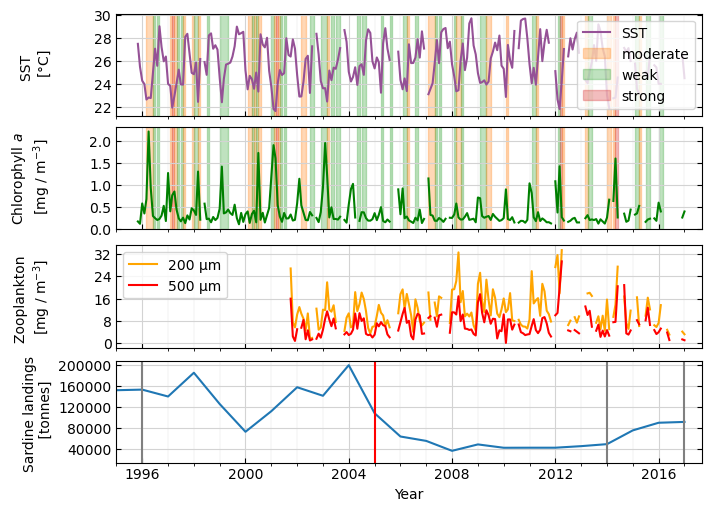

In [9]:
from matplotlib.ticker import MaxNLocator

plt.rcParams['figure.figsize'] = [7, 5]
f, ax = plt.subplots(4, 1, sharex='col', constrained_layout=True)  

color_dict={'SST':'#955196','P':'green','Z1':'orange','Z2':'red'}

ax[0].plot(CARIACO.date, CARIACO.SST, color=color_dict['SST'], label='SST')
ax[0].set_ylabel("SST \n"+r" [$\degree \mathrm{C}$]")

plot_state_as_color(x_data=CARIACO.date, state_data=CARIACO.ui, axis=ax[0])

ax[1].plot(CARIACO.date, CARIACO.Chlorophyll, color=color_dict['P'], label='Chlorophyll')
ax[1].set_ylabel("Chlorophyll $a$ \n"+r" [mg / $ \mathrm{m^{-3}}$]")

plot_state_as_color(x_data=CARIACO.date, state_data=CARIACO.ui, axis=ax[1])

ax[2].plot(CARIACO.date, CARIACO.Mesh200, color=color_dict['Z1'], label='200 µm')
ax[2].plot(CARIACO.date, CARIACO.Mesh500, color=color_dict['Z2'], label='500 µm')
ax[2].set_ylabel("Zooplankton \n"+r"[mg / $ \mathrm{ m^{-3} }$]")

ax[3].plot(Fish.date, Fish.sardinelandings)
ax[3].set_ylabel("Sardine landings \n"+r" [tonnes]")
ax[3].axvline(datetime.date(2005, 1, 1), color="red")
ax[3].axvline(datetime.date(1996, 1, 1), color="grey")
ax[3].axvline(datetime.date(2014, 1, 1), color="grey")
ax[3].axvline(datetime.date(2017, 1, 1), color="grey")



for i in range(4):
    ax[i].grid(True, color='lightgrey')
    ax[i].grid(True, lw=0.2, color='lightgrey', which="minor")
    ax[i].get_yaxis().set_major_locator(MaxNLocator(nbins=5))
    ax[i].get_xaxis().set_minor_locator(mdates.YearLocator())
    ax[i].tick_params(top=False, right=True, direction="in")

plt.setp((ax,),xlim=(datetime.date(1995, 1, 1), datetime.date(2017, 9, 1)))
# Setting the limits for all axes.
#plt.setp((ax,), ylim=(0,2.5)) #, xlim=(-1, 100)

# format labels
f.align_ylabels()

ax[0].set_xlabel('')
ax[3].set_xlabel('Year')

# show legend
# show legend
ax[0].legend()
ax[2].legend()



# OK, now I have an overview over the time series
## what I need next is a plot of all metrics for during upwelling and during 
## relaxation, so a bunch of boxplots

In [10]:
CARIACO.ui = CARIACO.ui.astype('category').cat.reorder_categories(['relaxed', 'weak','moderate', 'strong'])

CARIACO.upwelling = CARIACO.upwelling.astype('category').cat.reorder_categories(['relaxed', 'upwelling'])

<Axes: title={'center': 'Chlorophyll'}, xlabel='ui'>

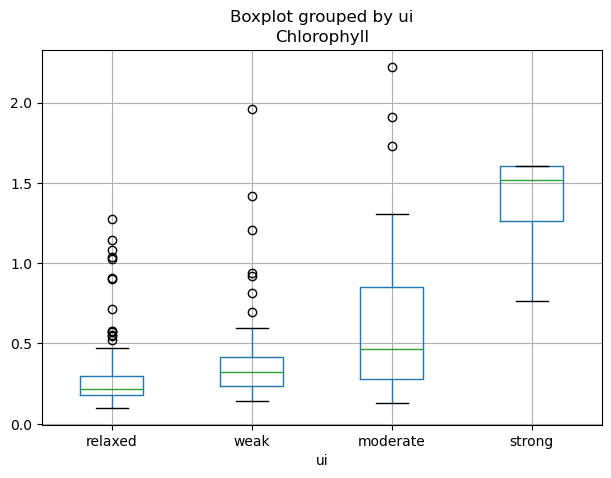

In [11]:
CARIACO.boxplot(column="Chlorophyll", by="ui")

Text(0, 0.5, 'NO3 \n[$\\mu M$]')

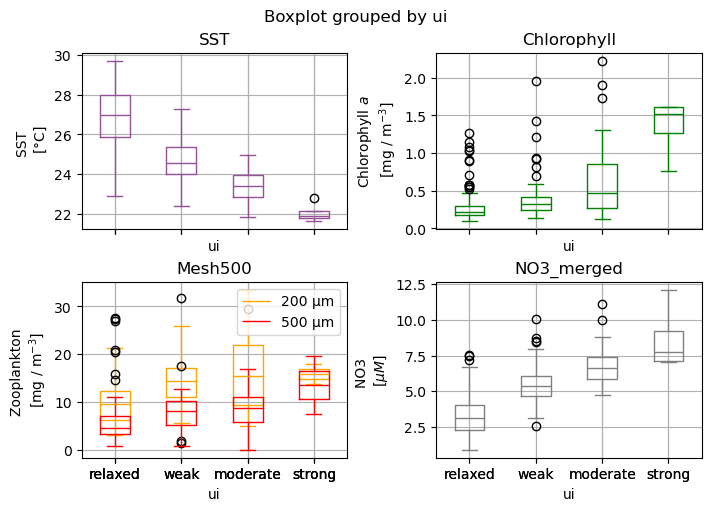

In [12]:
from matplotlib.ticker import MaxNLocator

plt.rcParams['figure.figsize'] = [7, 5]
f, ax = plt.subplots(2, 2, sharex='col', constrained_layout=True)  

color_dict={'SST':'#955196','P':'green','Z1':'orange','Z2':'red', 'NO3':'grey'}

CARIACO.boxplot(column="SST", by="ui", ax=ax[0,0], color=color_dict['SST'])
ax[0,0].set_ylabel("SST \n"+r" [$\degree \mathrm{C}$]")

CARIACO.boxplot(column="Chlorophyll", by="ui", ax=ax[0,1], color=color_dict['P'], label='Chlorophyll')
ax[0,1].set_ylabel("Chlorophyll $a$ \n"+r" [mg / $ \mathrm{m^{-3}}$]")


CARIACO.boxplot(column="Mesh200", by="ui", ax=ax[1,0], color=color_dict['Z1'], label='200 µm')
ax[1,0].set_ylabel("Zooplankton \n"+r"[mg / $ \mathrm{ m^{-3} }$]")

CARIACO.boxplot(column="Mesh500", by="ui", ax=ax[1,0], color=color_dict['Z2'], label='500 µm')

ax[1,0].legend()


CARIACO.boxplot(column="NO3_merged", by="ui", ax=ax[1,1], color=color_dict['NO3'])
ax[1,1].set_ylabel("NO3 \n"+r"[$\mu M$]")

In [13]:
# NOW Let's plot the size dist per upwelling or relaxed as stacked bar chart

In [14]:
CARIACO[CARIACO['ui']=='relaxed'].pico.mean()

0.3911670133827134

<Axes: title={'center': 'pico'}, xlabel='ui'>

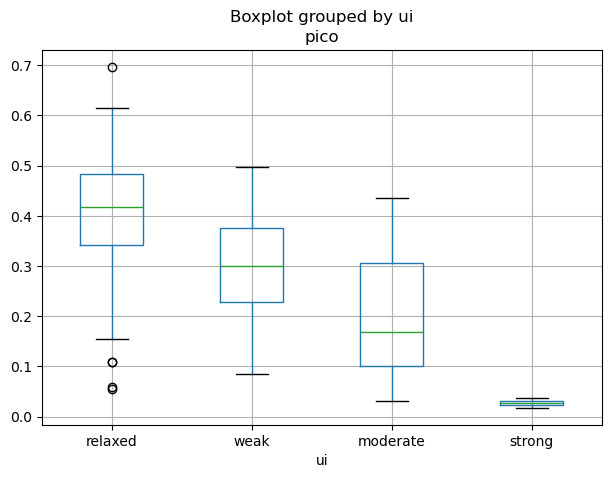

In [15]:
CARIACO.boxplot(column="pico", by="ui")

In [16]:
import seaborn as sns

<Axes: xlabel='ui', ylabel='micro'>

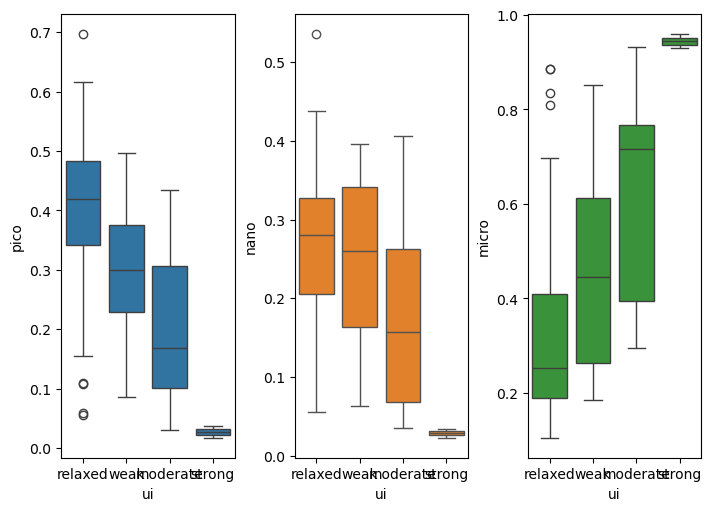

In [17]:
plt.rcParams['figure.figsize'] = [7, 5]
f, ax = plt.subplots(1, 3, sharex='col', constrained_layout=True)  

sns.boxplot(x='ui', y='pico', data=CARIACO, ax=ax[0])
sns.boxplot(x='ui', y='nano', data=CARIACO, ax=ax[1], color="#ff7f0e")
sns.boxplot(x='ui', y='micro', data=CARIACO, ax=ax[2], color="#2ca02c")

In [18]:
print(sns.color_palette().as_hex())

['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


Text(0.5, 0, 'Upwelling Index')

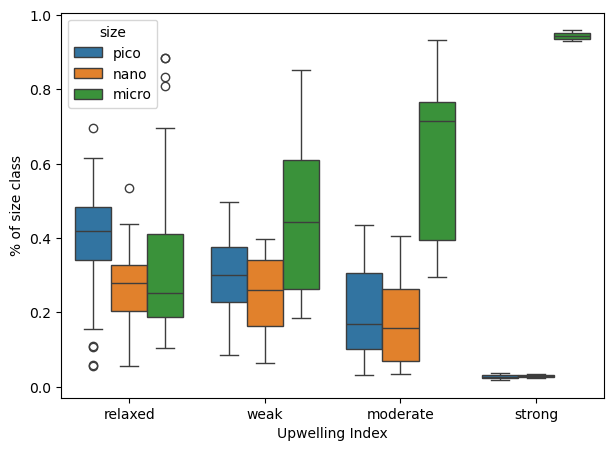

In [19]:
meltCar = pd.melt(CARIACO, id_vars=('date','ui'), value_vars=('pico', 'nano', 'micro'), var_name='size')
sns.boxplot(data=meltCar, x='ui', y='value', hue='size')
plt.ylabel("% of size class")
plt.xlabel("Upwelling Index")

# NOW let's compare size spectra per CLUSTER

In [20]:
# first split entire data frame by cluster time points from MS2

#GroupRed = extractGroups(year1="1996-01-01", year2="2003-12-31", year3="2014-01-01", year4="2016-12-31") #2016-12-31
#GroupBlue = extractGroups(year1="2004-01-01", year2="2013-12-31", year3="2017-06-01", year4="2017-12-31")

cluster1_mask = (CARIACO.date.dt.date>datetime.date(1996, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2003, 12, 31)) | \
                 (CARIACO.date.dt.date>datetime.date(2014, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2016, 12, 31))

cluster2_mask = (CARIACO.date.dt.date>datetime.date(2004, 1, 1)) & (CARIACO.date.dt.date<datetime.date(2013, 12, 31))

CARIACO["cluster"] = 'none'
CARIACO.loc[cluster1_mask, "cluster"] = 'cluster 1'
CARIACO.loc[cluster2_mask, "cluster"] = 'cluster 2'

Text(0.5, 0, 'Cluster')

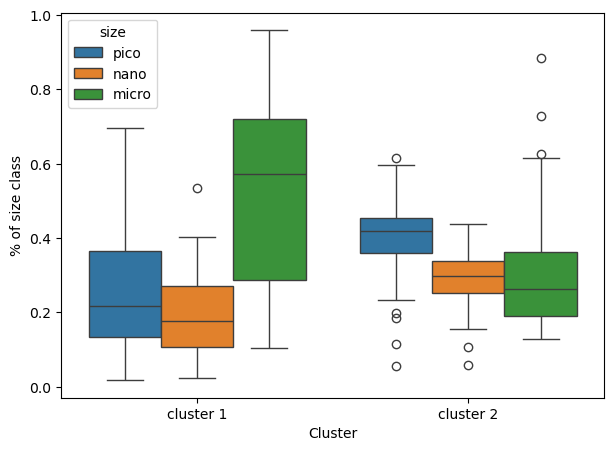

In [21]:
meltCar2 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('pico', 'nano', 'micro'), var_name='size')
sns.boxplot(data=meltCar2[meltCar2.cluster!='none'], x='cluster', y='value', hue='size')
plt.ylabel("% of size class")
plt.xlabel("Cluster")

In [32]:
meltCar2.groupby(['size','cluster']).mean().value

size   cluster  
micro  cluster 1    0.539241
       cluster 2    0.308458
       none         0.831815
nano   cluster 1    0.199274
       cluster 2    0.289811
       none         0.080643
pico   cluster 1    0.261485
       cluster 2    0.401731
       none         0.087542
Name: value, dtype: float64

Text(0.5, 0, 'Cluster')

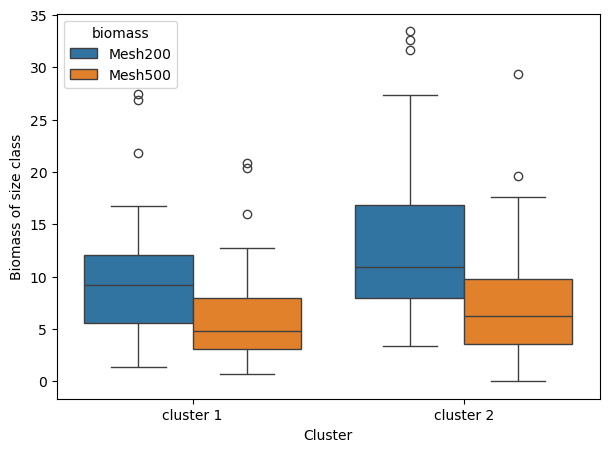

In [226]:
meltCar3 = pd.melt(CARIACO, id_vars=('date','cluster'), value_vars=('Mesh200', 'Mesh500'), var_name='biomass')
sns.boxplot(data=meltCar3[meltCar3.cluster!='none'], x='cluster', y='value', hue='biomass')
plt.ylabel("Biomass of size class")
plt.xlabel("Cluster")

<Axes: xlabel='ui', ylabel='count'>

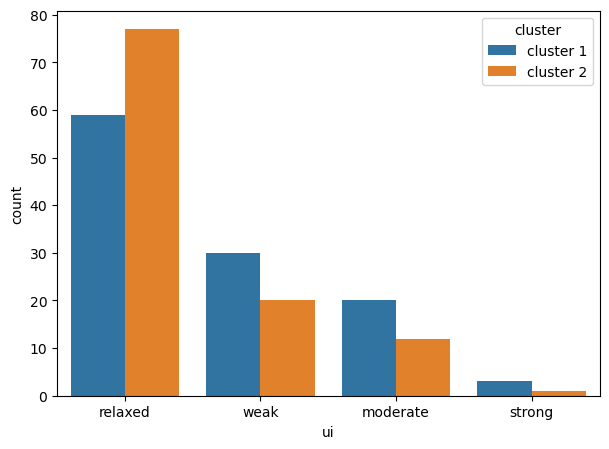

In [246]:
sns.countplot(data=CARIACO[CARIACO.cluster!='none'], x='ui', hue='cluster')

<Axes: xlabel='euphotic_depth'>

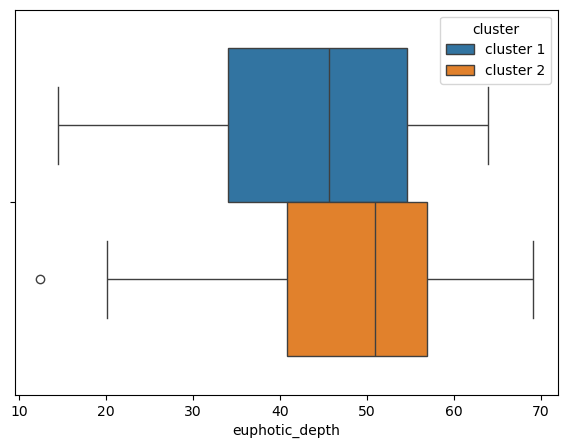

In [248]:
sns.boxplot(data=CARIACO[CARIACO.cluster!='none'], x='euphotic_depth', hue='cluster')

In [216]:
# Alright, now I will try and visualize the individual years and their respective upwelling strengths

CARIACO["year"] = CARIACO.date.dt.year

In [219]:
CARIACO.groupby(['ui', 'year'])

/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_29145/3745025561.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  CARIACO.groupby(['ui', 'year'])


/var/folders/98/6c9k3fxx2hl5k0_928yjt7qw0000gn/T/ipykernel_29145/1144757267.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  CARIACO.groupby(['year', 'ui']).ui.count().unstack().plot(kind='bar', stacked=True)


<Axes: xlabel='year'>

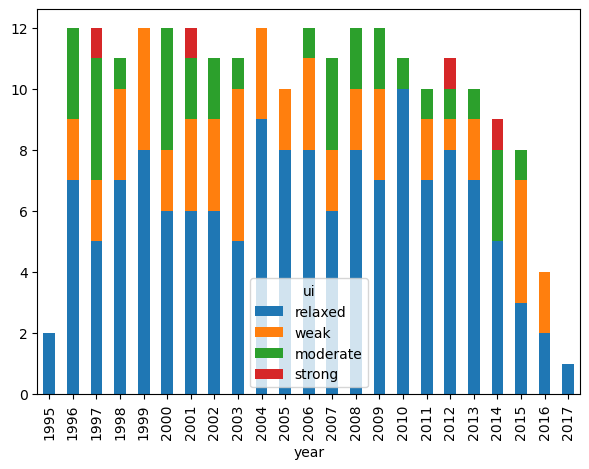

In [222]:
CARIACO.groupby(['year', 'ui']).ui.count().unstack().plot(kind='bar', stacked=True)

# CALCULATE METRICS!
### per Regime
- Euphotic Zone Depth
- Primary Production
- f-ratio
- New production per area
- New nutrient flux per volume

In [253]:
CARIACO["cluster"]

0           none
1           none
2           none
3      cluster 1
4      cluster 1
         ...    
250    cluster 1
251    cluster 1
252    cluster 1
253    cluster 1
254         none
Name: cluster, Length: 255, dtype: object

In [258]:
CARIACO[["euphotic_depth", "PrimaryProductivity", "Temperature", "cluster"]].groupby("cluster").mean()

,euphotic_depth,PrimaryProductivity,Temperature
cluster,,,
cluster 1,42.574138,1.222337,22.820225
cluster 2,48.002399,0.962282,23.470821
none,NaN,1.183853,23.071477


In [260]:
def f_ratio_calc(T, tp):
    """
    Empirical formula for calculation of the f-ratio from Laws et al. 2011
    T = temperature in degree celcius
    tp = total production in mg C m^-2 d^-1
    """
    ef = (0.5857 - 0.0165*T)*tp/(51.7 + tp)
    return ef

In [265]:
# cluster 1:
c1_ef = f_ratio_calc(22.820225, 1.222337*100)

# cluster 2:
c2_ef = f_ratio_calc(23.470821, 0.962282*100)

In [267]:
# new production per area:
c1_nppa = c1_ef*1.222337*100
c2_nppa = c2_ef*0.962282*100
c1_nppa, c2_nppa

(17.967591641470122, 12.421220321059776)

In [279]:
10 / 200  / 12.01 * 16/106 

0.0006284071449892386

In [276]:
# new nutrient flux per volume:
# convert mg C m^-2 d^-1 to mmol N m^-3 d^-1 via Redfield and g to mole converseion
c1_nnfpv = c1_nppa/42.574138 / 12.01 * 16/106
c2_nnfpv = c2_nppa/48.002399 / 12.01 * 16/106
c1_nnfpv, c2_nnfpv

(0.005304141667295177, 0.0032521639592385737)

In [280]:
# alright, so these are the values per mean conditions in cluster
# obviously these are rather low, so let's run the model 
# and see where chlorophyll ends up, whether it is in any way in agreement with the data.



In [ ]:
mg c = c/n

<Axes: xlabel='upwelling'>

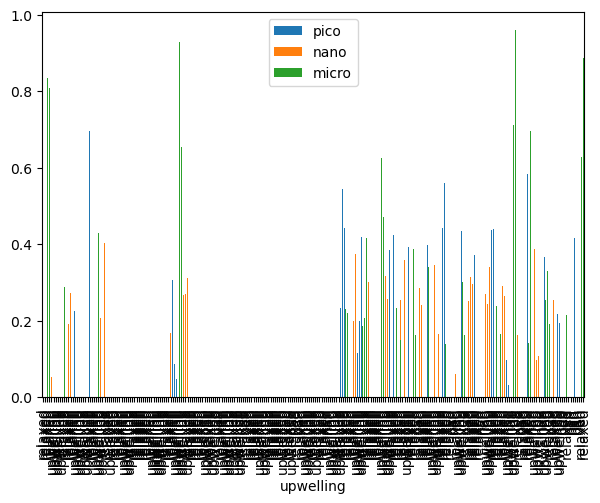

In [107]:
CARIACO[['upwelling', 'pico', 'nano', 'micro']].plot(x='upwelling', kind='bar')

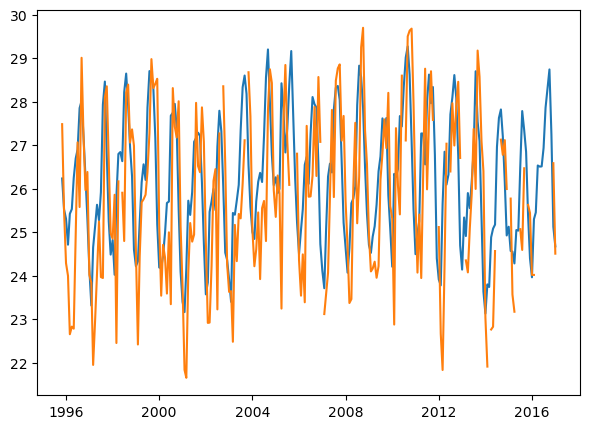

In [56]:
plt.plot(CARIACO.date,CARIACO.sst-273.15)
plt.plot(CARIACO.date,CARIACO.SST)

In [70]:
CARIACO.date

0     1995-11-01
1     1995-12-01
2     1996-01-01
3     1996-02-01
4     1996-03-01
         ...    
250   2016-09-01
251   2016-10-01
252   2016-11-01
253   2016-12-01
254   2017-01-01
Name: date, Length: 255, dtype: datetime64[ns]

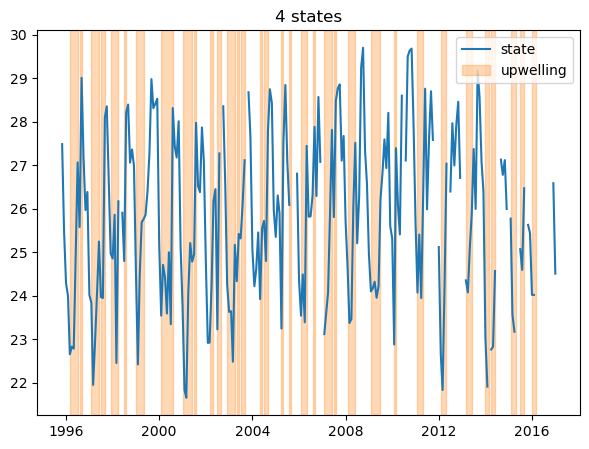

In [45]:
def plot_state_as_color(x_data, state_data, axis, add_labels=True):
    state_current = state_data[0]
    span_left = x_data[0]
    state_encountered = []
    for span_right, state_next in zip(x_data, state_data):
        if state_current != state_next:
            label = None
            if state_current not in state_encountered:
                state_encountered.append(state_current)
                if add_labels:
                    label = state_current
            if state_current == "upwelling":
                # plot section
                color = "C{}".format(state_encountered.index(state_current))
                axis.axvspan(span_left, span_right, color=color, alpha=0.3, label=label)
        
            # Update current state parameters
            span_left = span_right
            state_current = state_next

# Generate some data for the example
x_values = np.linspace(0, 10, 1000)
y_values = np.abs(np.sin(x_values))
state = [round(3*v) for v in y_values]

# figure with 4 states
plt.figure()
ax = plt.gca()
plt.plot(CARIACO.date, CARIACO.SST, label="state")
plot_state_as_color(x_data=CARIACO.date, state_data=CARIACO.justup, axis=ax)
plt.title("4 states")
plt.legend()

In [42]:
CARIACO['justup'] = CARIACO.upwelling
CARIACO.loc[CARIACO.upwelling!="upwelling", "justup"] = np.nan
CARIACO.justup

0            NaN
1            NaN
2            NaN
3            NaN
4      upwelling
         ...    
250          NaN
251          NaN
252          NaN
253          NaN
254          NaN
Name: justup, Length: 255, dtype: object

# OLD PLOT CODE AS INSPO:

In [ ]:
from matplotlib.ticker import MaxNLocator

color_dict={'N':'#955196','P':'green'}

plt.rcParams['figure.figsize'] = [5, 5]

f, ax = plt.subplots(2, 1, sharex='col', constrained_layout=True)  

for data, i, title in zip((chemostat_out, chemostat_out_sinu), (0,1), ('Sinusoidal forcing', 'Constant forcing')):
    # plot data + add labels
    data.Phytoplankton__value.plot(ax=ax[i], label='P', color=color_dict['P'])
    data.Nutrient__value.plot(ax=ax[i], label='N', color=color_dict['N'])
    ax[i].set_ylabel("["+chemostat_out_sinu.Phytoplankton__value.attrs['units']+"]")
    ax[i].set_title(title)

    # format plots
    ax[i].grid(True, color='lightgrey')
    ax[i].get_yaxis().set_major_locator(MaxNLocator(nbins=5))
    ax[i].tick_params(top=False, right=True, direction="in")


# Setting the limits for all axes.
plt.setp((ax,), xlim=(-1, 100), ylim=(0,1.5))

# format labels
f.align_ylabels()

ax[0].set_xlabel('')
ax[1].set_xlabel('Time [days]')

# show legend
ax[0].legend()

# add subplot labels
for i, label in enumerate(('(a)', '(b)')):
    ax[i].text(0.1, 1.15, label, transform=ax[i].transAxes,
      fontsize=16, fontweight='normal', va='top', ha='right')